In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
train_d = '/home/sanjeev/Downloads/Brain_dataset/train'

In [3]:
from keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255,                   
                                   validation_split=0.2)

In [4]:
batch_size = 64
img_height = 256
img_width = 256

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_d,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 253 files belonging to 2 classes.
Using 203 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  train_d,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [7]:
class_names = train_ds.class_names
print(class_names)

['no', 'yes']


In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(64, 256, 256, 3)
(64,)


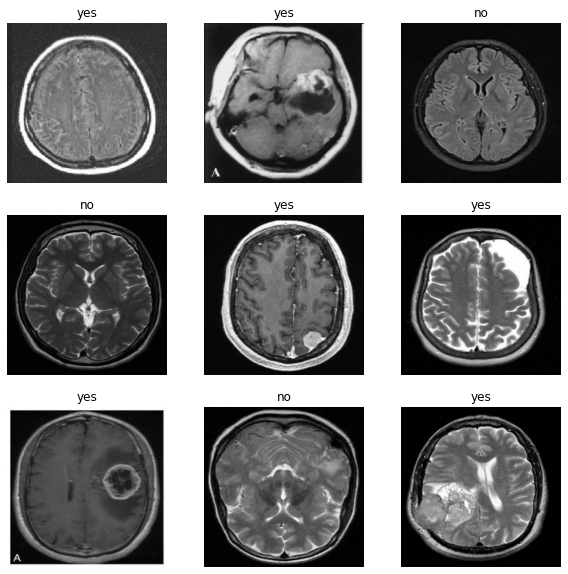

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

train_ds = train_ds.map(lambda x,y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
import numpy as np
normalization_layer = layers.Rescaling(1./255)

normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 0.9094693


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D , Flatten, Dropout
resnet_model = Sequential()

pretrained_model= tf.keras.applications.ResNet50(include_top=False,
                   input_shape=(256,256,3),
                   pooling='avg',classes=2,
                   weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable=False

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(4096, activation='relu'))
resnet_model.add(Dropout(0.2))

resnet_model.add(Dense(1, activation='sigmoid'))

In [13]:
resnet_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 4096)              8392704   
                                                                 
 dropout (Dropout)           (None, 4096)              0         
                                                                 
 dense_1 (Dense)             (None, 1)                 4097      
                                                                 
Total params: 31,984,513
Trainable params: 8,396,801
Non-trainable params: 23,587,712
_________________________________________________________________


In [14]:
from tensorflow.keras.optimizers import Adam
opt = Adam(learning_rate=0.001)
resnet_model.compile(optimizer=opt, loss=tf.keras.losses.BinaryCrossentropy (from_logits=False), metrics=['accuracy'])
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint("Resnet_50.h5", monitor='accuracy', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', period=1)
early = EarlyStopping(monitor='accuracy', min_delta=0, patience=9, verbose=1, mode='auto')

cb = [checkpoint, early]


In [15]:
history = resnet_model.fit(train_ds,epochs=32, validation_data=val_ds, callbacks = cb)

Epoch 1/32
4/4 [==============================] - ETA: 0s - loss: 5.1154 - accuracy: 0.6059
Epoch 1: accuracy improved from -inf to 0.60591, saving model to Resnet_50.h5
4/4 [==============================] - 25s 6s/step - loss: 5.1154 - accuracy: 0.6059 - val_loss: 7.3276 - val_accuracy: 0.3600
Epoch 2/32
4/4 [==============================] - ETA: 0s - loss: 2.5044 - accuracy: 0.6256
Epoch 2: accuracy improved from 0.60591 to 0.62562, saving model to Resnet_50.h5
4/4 [==============================] - 23s 6s/step - loss: 2.5044 - accuracy: 0.6256 - val_loss: 0.5707 - val_accuracy: 0.7400
Epoch 3/32
4/4 [==============================] - ETA: 0s - loss: 1.3916 - accuracy: 0.7340
Epoch 3: accuracy improved from 0.62562 to 0.73399, saving model to Resnet_50.h5
4/4 [==============================] - 23s 6s/step - loss: 1.3916 - accuracy: 0.7340 - val_loss: 2.8444 - val_accuracy: 0.3800
Epoch 4/32
4/4 [==============================] - ETA: 0s - loss: 0.8793 - accuracy: 0.7192
Epoch 4: ac

Epoch 30/32
4/4 [==============================] - ETA: 0s - loss: 0.1140 - accuracy: 0.9606
Epoch 30: accuracy did not improve from 0.97044
4/4 [==============================] - 22s 5s/step - loss: 0.1140 - accuracy: 0.9606 - val_loss: 0.2604 - val_accuracy: 0.9200
Epoch 31/32
4/4 [==============================] - ETA: 0s - loss: 0.0852 - accuracy: 0.9754
Epoch 31: accuracy improved from 0.97044 to 0.97537, saving model to Resnet_50.h5
4/4 [==============================] - 24s 6s/step - loss: 0.0852 - accuracy: 0.9754 - val_loss: 0.2396 - val_accuracy: 0.9000
Epoch 32/32
4/4 [==============================] - ETA: 0s - loss: 0.1165 - accuracy: 0.9557
Epoch 32: accuracy did not improve from 0.97537
4/4 [==============================] - 26s 7s/step - loss: 0.1165 - accuracy: 0.9557 - val_loss: 0.2580 - val_accuracy: 0.9200


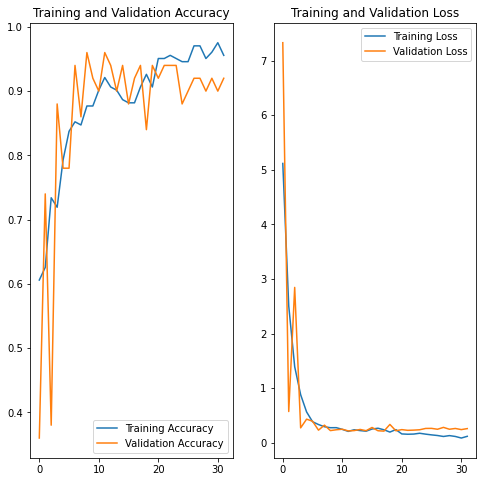

In [17]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(32)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:

from tensorflow.keras.preprocessing import image
new_model = tf.keras.models.load_model('./vgg16_1.h5')
test_score =model.evaluate(train_ds,val_ds)




In [ ]:
print(tes_score)

[0.4627149]
not Alzh


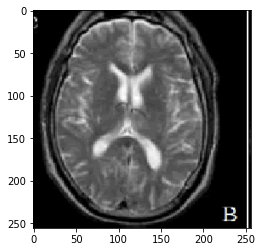

In [19]:
import numpy as np
from keras.preprocessing import image

img_path = "ss.png"
img = image.load_img(img_path, target_size=(256,256))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
images = np.vstack([x])
plt.imshow(img)

classes = resnet_model.predict(images, batch_size=batch_size)

print(classes[0])

if classes[0]>0.5:
    print("Alzh")
else:
    print("not Alzh")

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

In [ ]:
prediction